In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


df = pd.read_csv('Data/TEX.csv', parse_dates=['date_time'], na_values=['MISSING', 'EMPTY'])
df = df.set_index('date_time')

df.shape

# Print max and min values of the dates
print(f"Max date: {df.index.max()}")
print(f"Min date: {df.index.min()}")

print(df['cleaned demand (MW)'].describe())
print(df['cleaned demand (MW)'].isna().sum())

Max date: 2024-12-31 23:00:00
Min date: 2020-01-01 00:00:00
count    43848.000000
mean     48247.804643
std      10947.427884
min      27445.000000
25%      40373.750000
50%      45663.500000
75%      53990.250000
max      85559.000000
Name: cleaned demand (MW), dtype: float64
0


In [6]:
print(df.index.to_series().diff().value_counts()) 

date_time
0 days 01:00:00    43847
Name: count, dtype: int64


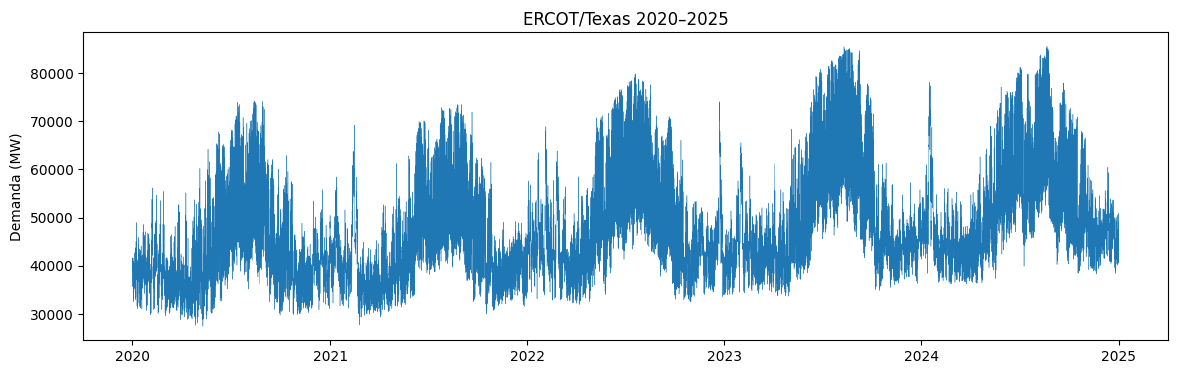

In [7]:
plt.figure(figsize=(14,4))
plt.plot(df.index, df['cleaned demand (MW)'], linewidth=0.3)
plt.ylabel('Demanda (MW)'); plt.title('ERCOT/Texas 2020–2025')
plt.show()

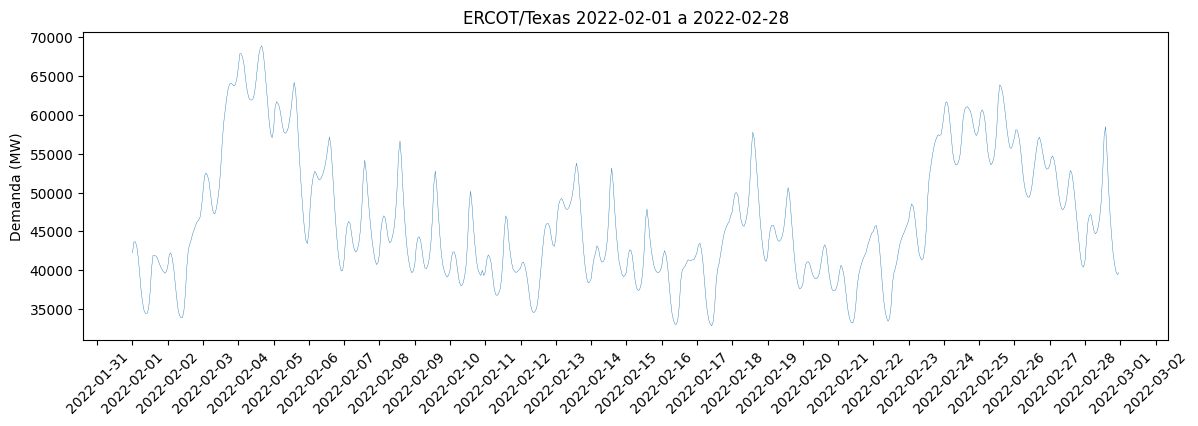

In [22]:

# Acercarse a las dos semanas con hora y todos los dias completos
sub = df.loc['2022-02-01':'2022-02-28', 'cleaned demand (MW)']
plt.figure(figsize=(14,4))
plt.plot(sub.index, sub.values, linewidth=0.3)
plt.ylabel('Demanda (MW)')
plt.title('ERCOT/Texas 2022-02-01 a 2022-02-28')

plt.gca().xaxis.set_major_locator(mdates.DayLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)

plt.show()

# Ciclos Observados

- Promedio por hora del día: Se observa un patrón diario con picos de demanda durante las horas de la tarde y noche, y valles durante la madrugada.

- Promedio por día de la semana: Se observa un patrón semanal con picos durante los dias laborales y descensos durante los fines de semana.

- Promedio por mes: Se observa un patrón anual con picos durante los meses de verano (junio, julio y agosto) y
descensos durante los meses de invierno (diciembre, enero y febrero).

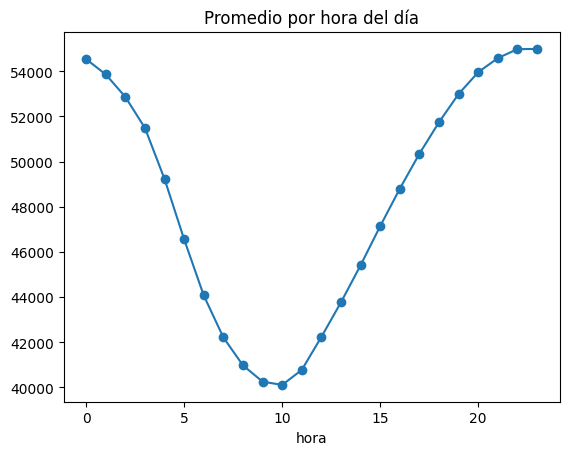

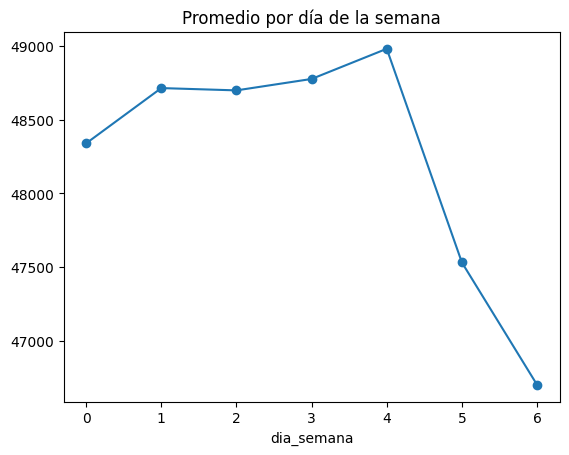

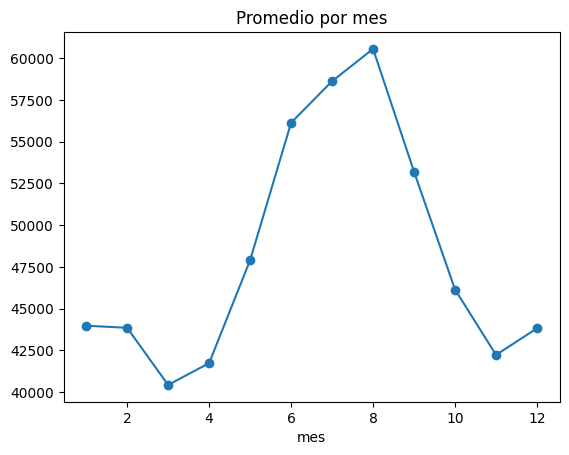

In [ ]:
df['hora'] = df.index.hour
df['dia_semana'] = df.index.dayofweek
df['mes'] = df.index.month

df.groupby('hora')['cleaned demand (MW)'].mean().plot(marker='o', title='Promedio por hora del día'); plt.show()
df.groupby('dia_semana')['cleaned demand (MW)'].mean().plot(marker='o', title='Promedio por día de la semana'); plt.show()
df.groupby('mes')['cleaned demand (MW)'].mean().plot(marker='o', title='Promedio por mes'); plt.show()